# Basic `optimex` Economics Example

This notebook extends the basic `optimex` workflow with time-dependent market prices, discounted costs, and cost optimization under a cumulative climate constraint.

## 1. System Overview

The example system has two final products and a shared upstream foreground product. The optimizer chooses when to install and operate foreground processes; the background inputs determine time-specific costs and indirect climate impacts.

```mermaid
flowchart LR
    classDef process fill:#ffffff,stroke:#111,stroke-width:1.5px,color:#111
    classDef product fill:#eeeeee,stroke:#888,stroke-width:1px,color:#111
    classDef bgstub fill:transparent,stroke:transparent,color:#555

    subgraph UP["Shared upstream foreground"]
        sip["Shared intermediate<br/>production"]:::process --> si(["Shared<br/>intermediate"]):::product
    end

    subgraph A["Product A routes"]
        ac["Product A<br/>conventional route"]:::process --> pa(["Product A"]):::product
        si --> aa["Product A<br/>advanced route"]:::process --> pa
    end

    subgraph B["Product B routes"]
        bc["Product B<br/>conventional route"]:::process --> pb(["Product B"]):::product
        si --> ba["Product B<br/>advanced route"]:::process --> pb
    end

    bg_ac[" "]:::bgstub -. "background inputs" .-> ac
    bg_aa[" "]:::bgstub -. "background inputs" .-> aa
    bg_bc[" "]:::bgstub -. "background inputs" .-> bc
    bg_ba[" "]:::bgstub -. "background inputs" .-> ba
    bg_sip[" "]:::bgstub -. "background inputs" .-> sip
```

Environmental impacts can come from direct foreground biosphere exchanges as well as from the time-specific background inputs used by those foreground processes. Economic prices in this example are attached to first-level background inputs via `market_price`; they are not attached to foreground products or internal foreground exchanges.

Therefore, `background_*` flows are costed inputs, not alternative routes selected by the optimizer.

| Foreground process | Foreground input | Installation-related background inputs | Operation-related background inputs | Direct operation CO2 | End-of-life background |
|---|---|---|---|---|---|
| `product_a_conventional` | none | `background_capex_1` | `background_opex_1`, `background_opex_2` | high | `background_eol` |
| `product_a_advanced` | `shared_intermediate` | `background_capex_2` | `background_opex_2` | low | `background_eol` |
| `product_b_conventional` | none | `background_capex_1`, `background_capex_2` | `background_opex_1`, `background_opex_3` | high | `background_eol` |
| `product_b_advanced` | `shared_intermediate` | `background_capex_1`, `background_capex_2` | `background_opex_3` | low | `background_eol` |
| `shared_intermediate_production` | none | `background_capex_2` | `background_opex_4` | medium | `background_eol` |

The background inputs are deliberately abstract, but each one has a specific role in the example:

| Background flow | Role in the model |
|---|---|
| `background_capex_1` | Conventional construction input; also used in `product_b_advanced` to keep the advanced route from being purely "new technology". |
| `background_capex_2` | Advanced construction input; expensive in early years, cheaper in later years. |
| `background_opex_1` | Shared conventional operating input; low-cost early on, but becomes more expensive over time. |
| `background_opex_2` | Product A-specific operating input; used by both A routes, but the advanced route uses less and benefits from vintage improvements. |
| `background_opex_3` | Product B-specific operating input; similar to `background_opex_2`, but its price falls later to create a staggered portfolio transition. |
| `background_opex_4` | Operating input for `shared_intermediate_production`; represents the cost of the shared upstream system. |
| `background_eol` | Small end-of-life input; grouped with installation-related costs because it is not marked `operation=True`. |

## 2. Database Setup

We create a standalone Brightway project with:

- one biosphere flow: `CO2`
- three time-specific background databases: 2025, 2035, and 2050
- one foreground database with two final products, four final-product routes, and one shared upstream process

In [32]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
import bw2data as bd
from bw_temporalis import TemporalDistribution, easy_timedelta_distribution

bd.projects.set_current("optimex_basic_example_econ")

for db_name in ["biosphere3", "db_2025", "db_2035", "db_2050", "foreground"]:
    if db_name in bd.databases:
        del bd.databases[db_name]

### Biosphere

In [33]:
biosphere_data = {
    ("biosphere3", "CO2"): {
        "type": bd.labels.biosphere_node_default,
        "name": "carbon dioxide",
        "unit": "kg",
    },
}

bd.Database("biosphere3").write(biosphere_data)

100%|██████████| 1/1 [00:00<?, ?it/s]


13:16:50+0200 [info     ] Vacuuming database            


### Characterization Method

In [34]:
method_climate_change = ("GWP", "basic_econ")

bd.Method(method_climate_change).register(unit="kg CO2-eq")
bd.Method(method_climate_change).write(
    [
        (("biosphere3", "CO2"), 1.0),
    ]
)

### Background Databases

The background databases contain abstract first-level inputs. Their climate intensities change over time; market prices are added in the next section using `optimex.economics.set_market_prices`.

In [35]:
background_flows = [
    "background_capex_1",
    "background_capex_2",
    "background_opex_1",
    "background_opex_2",
    "background_opex_3",
    "background_opex_4",
    "background_eol",
]

background_specs = {
    "db_2025": {
        "year": 2025,
        "co2": {
            "background_capex_1": 3.0,
            "background_capex_2": 2.8,
            "background_opex_1": 10.0,
            "background_opex_2": 5.0,
            "background_opex_3": 6.0,
            "background_opex_4": 3.0,
            "background_eol": 0.3,
        },
    },
    "db_2035": {
        "year": 2035,
        "co2": {
            "background_capex_1": 2.6,
            "background_capex_2": 2.0,
            "background_opex_1": 8.0,
            "background_opex_2": 3.0,
            "background_opex_3": 4.2,
            "background_opex_4": 2.0,
            "background_eol": 0.25,
        },
    },
    "db_2050": {
        "year": 2050,
        "co2": {
            "background_capex_1": 2.3,
            "background_capex_2": 1.3,
            "background_opex_1": 6.5,
            "background_opex_2": 1.5,
            "background_opex_3": 2.0,
            "background_opex_4": 1.0,
            "background_eol": 0.2,
        },
    },
}


def make_background_data(db_name, co2_intensities):
    data = {}
    for flow_code, co2_amount in co2_intensities.items():
        data[(db_name, flow_code)] = {
            "name": flow_code,
            "location": "GLO",
            "unit": "unit",
            "type": bd.labels.chimaera_node_default,
            "reference product": flow_code,
            "exchanges": [
                {
                    "amount": 1.0,
                    "type": bd.labels.production_edge_default,
                    "input": (db_name, flow_code),
                },
                {
                    "amount": co2_amount,
                    "type": bd.labels.biosphere_edge_default,
                    "input": ("biosphere3", "CO2"),
                },
            ],
        }
    return data


for db_name, spec in background_specs.items():
    db = bd.Database(db_name)
    db.write(make_background_data(db_name, spec["co2"]))
    db.metadata["representative_time"] = datetime(spec["year"], 1, 1).isoformat()
    db.register()

100%|██████████| 7/7 [00:00<00:00, 6114.15it/s]


13:16:50+0200 [info     ] Vacuuming database            


100%|██████████| 7/7 [00:00<?, ?it/s]


13:16:50+0200 [info     ] Vacuuming database            


100%|██████████| 7/7 [00:00<?, ?it/s]


13:16:51+0200 [info     ] Vacuuming database            


In [36]:
co2_intensity_table = pd.DataFrame(
    [
        {"year": spec["year"], "background_flow": flow, "kg_CO2_per_unit": amount}
        for spec in background_specs.values()
        for flow, amount in spec["co2"].items()
    ]
)

co2_intensity_table.pivot(
    index="background_flow",
    columns="year",
    values="kg_CO2_per_unit",
)

year,2025,2035,2050
background_flow,,,
background_capex_1,3.0,2.60,2.3
background_capex_2,2.8,2.00,1.3
background_eol,0.3,0.25,0.2
background_opex_1,10.0,8.00,6.5
background_opex_2,5.0,3.00,1.5
background_opex_3,6.0,4.20,2.0
background_opex_4,3.0,2.00,1.0


### Economic Price Assumptions

In [37]:
from optimex.economics import set_market_prices

background_databases = {
    spec["year"]: db_name for db_name, spec in background_specs.items()
}

price_points = {
    "background_capex_1": {2025: 4.0, 2035: 4.5, 2050: 5.0},
    "background_capex_2": {2025: 18.0, 2035: 12.0, 2050: 8.0},
    "background_opex_1": {2025: 1.5, 2035: 2.4, 2050: 3.5},
    "background_opex_2": {2025: 4.5, 2035: 2.4, 2050: 1.3},
    "background_opex_3": {2025: 4.8, 2035: 3.6, 2050: 1.6},
    "background_opex_4": {2025: 5.0, 2035: 3.2, 2050: 1.5},
    "background_eol": {2025: 0.3, 2035: 0.3, 2050: 0.3},
}

price_data = pd.DataFrame(
    [
        {
            "name": flow,
            "location": "GLO",
            "year": year,
            "price": price,
        }
        for flow, prices in price_points.items()
        for year, price in prices.items()
    ]
)

set_market_prices(
    price_data=price_data,
    background_databases=background_databases,
)

price_data.pivot(index="name", columns="year", values="price")

year,2025,2035,2050
name,,,
background_capex_1,4.0,4.5,5.0
background_capex_2,18.0,12.0,8.0
background_eol,0.3,0.3,0.3
background_opex_1,1.5,2.4,3.5
background_opex_2,4.5,2.4,1.3
background_opex_3,4.8,3.6,1.6
background_opex_4,5.0,3.2,1.5


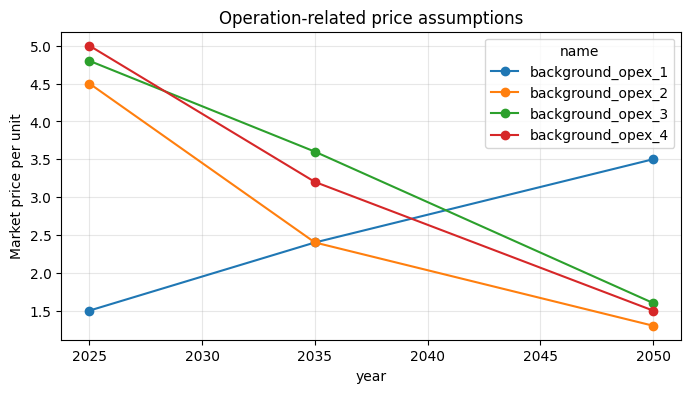

In [38]:
price_plot_data = price_data.pivot(index="year", columns="name", values="price")

ax = price_plot_data[
    [
        "background_opex_1",
        "background_opex_2",
        "background_opex_3",
        "background_opex_4",
    ]
].plot(marker="o", figsize=(8, 4))
ax.set_ylabel("Market price per unit")
ax.set_title("Operation-related price assumptions")
ax.grid(True, alpha=0.3)
plt.show()

### Foreground Database

The foreground database contains the decision-relevant processes. Exchanges marked with `operation=True` scale with operational level; exchanges without `operation=True` are installation-related in the optimization accounting. In this example, that includes construction and end-of-life exchanges.

In [39]:
foreground = bd.Database("foreground")
foreground.register()

In [40]:
def construction_td():
    return TemporalDistribution(
        date=np.array([0], dtype="timedelta64[Y]"),
        amount=np.array([1.0]),
    )


def operation_td(lifetime):
    return easy_timedelta_distribution(
        start=0,
        end=lifetime,
        steps=lifetime + 1,
        resolution="Y",
        kind="uniform",
    )


def eol_td(lifetime):
    return TemporalDistribution(
        date=np.array([lifetime + 1], dtype="timedelta64[Y]"),
        amount=np.array([1.0]),
    )

In [41]:
lifetime_a_conventional = 10
lifetime_a_advanced = 12
lifetime_b_conventional = 10
lifetime_b_advanced = 12
lifetime_shared = 20

foreground_data = {
    ("foreground", "product_a"): {
        "name": "Product A",
        "unit": "unit",
        "type": bd.labels.product_node_default,
    },
    ("foreground", "product_b"): {
        "name": "Product B",
        "unit": "unit",
        "type": bd.labels.product_node_default,
    },
    ("foreground", "shared_intermediate"): {
        "name": "Shared intermediate",
        "unit": "unit",
        "type": bd.labels.product_node_default,
    },
    ("foreground", "product_a_conventional"): {
        "name": "Product A conventional route",
        "location": "GLO",
        "type": bd.labels.process_node_default,
        "operation_time_limits": (0, lifetime_a_conventional),
        "exchanges": [
            {
                "amount": 1.0,
                "type": bd.labels.production_edge_default,
                "input": ("foreground", "product_a"),
                "temporal_distribution": operation_td(lifetime_a_conventional),
                "operation": True,
            },
            {
                "amount": 1.0,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_capex_1"),
                "temporal_distribution": construction_td(),
            },
            {
                "amount": 0.7,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_opex_1"),
                "temporal_distribution": operation_td(lifetime_a_conventional),
                "operation": True,
            },
            {
                "amount": 1.4,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_opex_2"),
                "temporal_distribution": operation_td(lifetime_a_conventional),
                "operation": True,
            },
            {
                "amount": 7.0,
                "type": bd.labels.biosphere_edge_default,
                "input": ("biosphere3", "CO2"),
                "temporal_distribution": operation_td(lifetime_a_conventional),
                "operation": True,
            },
            {
                "amount": 0.2,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_eol"),
                "temporal_distribution": eol_td(lifetime_a_conventional),
            },
        ],
    },
    ("foreground", "product_a_advanced"): {
        "name": "Product A advanced route",
        "location": "GLO",
        "type": bd.labels.process_node_default,
        "operation_time_limits": (0, lifetime_a_advanced),
        "exchanges": [
            {
                "amount": 1.0,
                "type": bd.labels.production_edge_default,
                "input": ("foreground", "product_a"),
                "temporal_distribution": operation_td(lifetime_a_advanced),
                "operation": True,
            },
            {
                "amount": 0.6,
                "type": bd.labels.consumption_edge_default,
                "input": ("foreground", "shared_intermediate"),
                "temporal_distribution": operation_td(lifetime_a_advanced),
                "operation": True,
            },
            {
                "amount": 1.3,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_capex_2"),
                "temporal_distribution": construction_td(),
            },
            {
                "amount": 0.6,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_opex_2"),
                "temporal_distribution": operation_td(lifetime_a_advanced),
                "operation": True,
            },
            {
                "amount": 1.0,
                "type": bd.labels.biosphere_edge_default,
                "input": ("biosphere3", "CO2"),
                "temporal_distribution": operation_td(lifetime_a_advanced),
                "operation": True,
            },
            {
                "amount": 0.25,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_eol"),
                "temporal_distribution": eol_td(lifetime_a_advanced),
            },
        ],
    },
    ("foreground", "product_b_conventional"): {
        "name": "Product B conventional route",
        "location": "GLO",
        "type": bd.labels.process_node_default,
        "operation_time_limits": (0, lifetime_b_conventional),
        "exchanges": [
            {
                "amount": 1.0,
                "type": bd.labels.production_edge_default,
                "input": ("foreground", "product_b"),
                "temporal_distribution": operation_td(lifetime_b_conventional),
                "operation": True,
            },
            {
                "amount": 1.1,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_capex_1"),
                "temporal_distribution": construction_td(),
            },
            {
                "amount": 0.4,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_capex_2"),
                "temporal_distribution": construction_td(),
            },
            {
                "amount": 0.9,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_opex_1"),
                "temporal_distribution": operation_td(lifetime_b_conventional),
                "operation": True,
            },
            {
                "amount": 1.5,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_opex_3"),
                "temporal_distribution": operation_td(lifetime_b_conventional),
                "operation": True,
            },
            {
                "amount": 9.0,
                "type": bd.labels.biosphere_edge_default,
                "input": ("biosphere3", "CO2"),
                "temporal_distribution": operation_td(lifetime_b_conventional),
                "operation": True,
            },
            {
                "amount": 0.3,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_eol"),
                "temporal_distribution": eol_td(lifetime_b_conventional),
            },
        ],
    },
    ("foreground", "product_b_advanced"): {
        "name": "Product B advanced route",
        "location": "GLO",
        "type": bd.labels.process_node_default,
        "operation_time_limits": (0, lifetime_b_advanced),
        "exchanges": [
            {
                "amount": 1.0,
                "type": bd.labels.production_edge_default,
                "input": ("foreground", "product_b"),
                "temporal_distribution": operation_td(lifetime_b_advanced),
                "operation": True,
            },
            {
                "amount": 1.2,
                "type": bd.labels.consumption_edge_default,
                "input": ("foreground", "shared_intermediate"),
                "temporal_distribution": operation_td(lifetime_b_advanced),
                "operation": True,
            },
            {
                "amount": 0.4,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_capex_1"),
                "temporal_distribution": construction_td(),
            },
            {
                "amount": 1.5,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_capex_2"),
                "temporal_distribution": construction_td(),
            },
            {
                "amount": 0.7,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_opex_3"),
                "temporal_distribution": operation_td(lifetime_b_advanced),
                "operation": True,
            },
            {
                "amount": 1.3,
                "type": bd.labels.biosphere_edge_default,
                "input": ("biosphere3", "CO2"),
                "temporal_distribution": operation_td(lifetime_b_advanced),
                "operation": True,
            },
            {
                "amount": 0.35,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_eol"),
                "temporal_distribution": eol_td(lifetime_b_advanced),
            },
        ],
    },
    ("foreground", "shared_intermediate_production"): {
        "name": "Shared intermediate production",
        "location": "GLO",
        "type": bd.labels.process_node_default,
        "operation_time_limits": (0, lifetime_shared),
        "exchanges": [
            {
                "amount": 1.0,
                "type": bd.labels.production_edge_default,
                "input": ("foreground", "shared_intermediate"),
                "temporal_distribution": operation_td(lifetime_shared),
                "operation": True,
            },
            {
                "amount": 0.8,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_capex_2"),
                "temporal_distribution": construction_td(),
            },
            {
                "amount": 1.0,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_opex_4"),
                "temporal_distribution": operation_td(lifetime_shared),
                "operation": True,
            },
            {
                "amount": 1.5,
                "type": bd.labels.biosphere_edge_default,
                "input": ("biosphere3", "CO2"),
                "temporal_distribution": operation_td(lifetime_shared),
                "operation": True,
            },
            {
                "amount": 0.15,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2025", "background_eol"),
                "temporal_distribution": eol_td(lifetime_shared),
            },
        ],
    },
}

fg = bd.Database("foreground")
fg.write(foreground_data)
fg.register()

100%|██████████| 8/8 [00:00<?, ?it/s]


13:16:51+0200 [info     ] Vacuuming database            


### Demand

In [42]:
years = range(2025, 2051)

td_product_a = TemporalDistribution(
    date=np.array(
        [datetime(year, 1, 1).isoformat() for year in years],
        dtype="datetime64[s]",
    ),
    amount=np.full(len(years), 10.0),
)

td_product_b = TemporalDistribution(
    date=np.array(
        [datetime(year, 1, 1).isoformat() for year in years],
        dtype="datetime64[s]",
    ),
    amount=np.linspace(6.0, 14.0, len(years)),
)

functional_demand = {
    bd.get_node(database="foreground", name="Product A"): td_product_a,
    bd.get_node(database="foreground", name="Product B"): td_product_b,
}

pd.DataFrame(
    {
        "year": list(years),
        "product_a": td_product_a.amount,
        "product_b": td_product_b.amount,
    }
).head()

,year,product_a,product_b
0,2025,10.0,6.00
1,2026,10.0,6.32
2,2027,10.0,6.64
3,2028,10.0,6.96
4,2029,10.0,7.28


## 3. LCA Processing

The LCA processor extracts the time-explicit foreground tensors, background inventories, background mapping, characterization tensor, and annual cost inputs.

In [43]:
from optimex import lca_processor

lca_config = lca_processor.LCAConfig(
    demand=functional_demand,
    temporal={
        "start_date": datetime(2025, 1, 1),
        "temporal_resolution": "year",
        "time_horizon": 41,
    },
    characterization_methods=[
        {
            "category_name": "climate_change",
            "brightway_method": method_climate_change,
        },
    ],
)

lca_data_processor = lca_processor.LCADataProcessor(lca_config)

2026-06-26 13:16:52.062 | INFO     | optimex.lca_processor:_parse_demand:460 - Identified demand in system time range of %s for products %s
2026-06-26 13:16:52.084 | INFO     | optimex.lca_processor:_construct_foreground_tensors:699 - Constructed foreground tensors.
2026-06-26 13:16:52.085 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Technosphere (external) shape: (5 processes, 7 flows, 22 years) with 103 total entries.
2026-06-26 13:16:52.088 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Internal demand shape: (2 processes, 1 flows, 13 years) with 26 total entries.
2026-06-26 13:16:52.089 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Biosphere shape: (5 processes, 1 flows, 21 years) with 69 total entries.
2026-06-26 13:16:52.091 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Production shape: (5 processes, 3 flows, 21 years) with 69 total entries.
2026-06-26 13:16:52.100 | INFO     | optimex.lca_processor:_calculate_i

In [44]:
from optimex import converter

manager = converter.ModelInputManager()
optimization_model_inputs = manager.parse_from_lca_processor(lca_data_processor)

data_dir = Path("data/basic_example_econ")
data_dir.mkdir(parents=True, exist_ok=True)
model_inputs_path = data_dir / "model_inputs.json"

manager.save_inputs(str(model_inputs_path))
optimization_model_inputs = manager.load_inputs(str(model_inputs_path))

model_inputs_path

WindowsPath('data/basic_example_econ/model_inputs.json')

### Check Annual Interpolated Cost Inputs

The price table above only defines values for the background snapshots in 2025, 2035, and 2050. During LCA processing, `optimex` maps those snapshot prices onto every system year and separates them into installation-related and operation-related cost inputs based on the foreground exchange phase.

The table below is a compact check that this annual interpolation and cap/op split happened as expected.

In [45]:
def tidy_cost_inputs(model_inputs):
    rows = []
    for phase, costs in [
        ("installation_related", model_inputs.intermediate_costs_cap or {}),
        ("operation_related", model_inputs.intermediate_costs_op or {}),
    ]:
        for (background_flow, year), price in costs.items():
            rows.append(
                {
                    "phase": phase,
                    "background_flow": background_flow,
                    "year": year,
                    "price": price,
                }
            )
    return pd.DataFrame(rows).sort_values(["phase", "background_flow", "year"])


cost_input_table = tidy_cost_inputs(optimization_model_inputs)
cost_input_table[
    cost_input_table["year"].isin([2025, 2030, 2035, 2040, 2050])
].head(20)

,phase,background_flow,year,price
0,installation_related,background_capex_1,2025,4.000000
5,installation_related,background_capex_1,2030,4.250000
10,installation_related,background_capex_1,2035,4.500000
15,installation_related,background_capex_1,2040,4.666667
25,installation_related,background_capex_1,2050,5.000000
52,installation_related,background_capex_2,2025,18.000000
57,installation_related,background_capex_2,2030,15.000000
62,installation_related,background_capex_2,2035,12.000000
67,installation_related,background_capex_2,2040,10.666667
77,installation_related,background_capex_2,2050,8.000000


In [46]:
installation_flows = set(
    cost_input_table.loc[
        cost_input_table["phase"] == "installation_related",
        "background_flow",
    ]
)
operation_flows = set(
    cost_input_table.loc[
        cost_input_table["phase"] == "operation_related",
        "background_flow",
    ]
)

assert {"background_capex_1", "background_capex_2", "background_eol"} <= installation_flows
assert {"background_opex_1", "background_opex_2", "background_opex_3", "background_opex_4"} <= operation_flows
assert "background_opex_1" not in installation_flows
assert "background_capex_1" not in operation_flows

## 4. Optimization Scenarios

We solve three scenarios:

1. **Climate-only optimization**: the original environmental `optimex` objective.
2. **Cost-only optimization**: discounted economic cost minimization.
3. **Cost optimization with a cumulative climate constraint**: the economic objective under an environmental budget.

Costs are available in all scenarios, including the climate-only scenario.

In [47]:
from optimex import optimizer

solver_name = "highs"

existing_capacity = {
    ("product_a_conventional", 2018): 6.0,
    ("product_b_conventional", 2020): 5.0,
}

vintage_improvements = {
    ("product_a_advanced", "background_opex_2", 2025): 1.00,
    ("product_a_advanced", "background_opex_2", 2035): 0.85,
    ("product_a_advanced", "background_opex_2", 2050): 0.75,
    ("product_b_advanced", "background_opex_3", 2025): 1.00,
    ("product_b_advanced", "background_opex_3", 2035): 0.90,
    ("product_b_advanced", "background_opex_3", 2050): 0.78,
    ("shared_intermediate_production", "background_opex_4", 2025): 1.00,
    ("shared_intermediate_production", "background_opex_4", 2035): 0.90,
    ("shared_intermediate_production", "background_opex_4", 2050): 0.82,
}

scenario_base_inputs = manager.override(
    existing_capacity=existing_capacity,
    vintage_improvements=vintage_improvements,
    discount_rate=0.03,
    discount_reference_year=2025,
)

In [48]:
def real_total_impact(model, category="climate_change"):
    return (
        pyo.value(model.total_impact[category])
        * model.scales["foreground"]
        * model.scales["characterization"][category]
    )


def total_cost_by_phase(model):
    installation_related = sum(pyo.value(model.cost_cap[t]) for t in model.SYSTEM_TIME)
    operation_related = sum(pyo.value(model.cost_op[t]) for t in model.SYSTEM_TIME)
    return {
        "discounted_total_cost": pyo.value(model.total_cost),
        "undiscounted_installation_related_cost": installation_related,
        "undiscounted_operation_related_cost": operation_related,
        "undiscounted_total_cost": installation_related + operation_related,
    }


def solve_scenario(model_inputs, name, objective, cumulative_limits=None):
    scenario_inputs = model_inputs.model_copy(deep=True)
    if cumulative_limits is not None:
        scenario_inputs.cumulative_category_impact_limits = cumulative_limits

    model = optimizer.create_model(
        scenario_inputs,
        name=name,
        objective_category="climate_change",
        objective=objective,
    )
    solved_model, objective_value, results = optimizer.solve_model(
        model,
        solver_name=solver_name,
        tee=False,
    )
    assert results.solver.termination_condition == pyo.TerminationCondition.optimal
    return solved_model, objective_value, results

### Scenario 1: Climate-only Optimization

In [49]:
climate_model, climate_objective, climate_results = solve_scenario(
    scenario_base_inputs,
    name="basic_econ_climate_only",
    objective="environmental",
)

2026-06-26 13:16:52.592 | INFO     | optimex.optimizer:create_model:126 - Creating sets
2026-06-26 13:16:52.600 | INFO     | optimex.optimizer:create_model:168 - Creating parameters
2026-06-26 13:16:52.603 | INFO     | optimex.optimizer:create_model:498 - Creating variables
2026-06-26 13:16:53.952 | INFO     | optimex.optimizer:solve_model:1232 - Solver [highs] termination: optimal
2026-06-26 13:16:53.987 | INFO     | optimex.optimizer:solve_model:1250 - Objective (scaled): 2251.13
2026-06-26 13:16:53.991 | INFO     | optimex.optimizer:solve_model:1251 - Objective (real):   3376.7


### Scenario 2: Cost-only Optimization

Even when the objective is economic cost, `objective_category="climate_change"` is still provided so the model builds climate impact expressions for reporting and constraints.

In [50]:
cost_model, cost_objective, cost_results = solve_scenario(
    scenario_base_inputs,
    name="basic_econ_cost_only",
    objective="cost",
)

2026-06-26 13:16:54.015 | INFO     | optimex.optimizer:create_model:126 - Creating sets
2026-06-26 13:16:54.019 | INFO     | optimex.optimizer:create_model:168 - Creating parameters
2026-06-26 13:16:54.025 | INFO     | optimex.optimizer:create_model:498 - Creating variables
2026-06-26 13:16:55.611 | INFO     | optimex.optimizer:solve_model:1232 - Solver [highs] termination: optimal
2026-06-26 13:16:55.649 | INFO     | optimex.optimizer:solve_model:1240 - Objective (cost): 2374.21


### Scenario 3: Cost Optimization with a Climate Constraint

In [51]:
climate_only_impact = real_total_impact(climate_model)
cost_only_impact = real_total_impact(cost_model)

climate_budget = climate_only_impact + 0.45 * (
    cost_only_impact - climate_only_impact
)

constrained_model, constrained_objective, constrained_results = solve_scenario(
    scenario_base_inputs,
    name="basic_econ_cost_with_climate_constraint",
    objective="cost",
    cumulative_limits={"climate_change": climate_budget},
)

climate_budget

2026-06-26 13:16:55.760 | INFO     | optimex.optimizer:create_model:126 - Creating sets
2026-06-26 13:16:55.763 | INFO     | optimex.optimizer:create_model:168 - Creating parameters
2026-06-26 13:16:55.771 | INFO     | optimex.optimizer:create_model:498 - Creating variables
2026-06-26 13:16:57.066 | INFO     | optimex.optimizer:solve_model:1232 - Solver [highs] termination: optimal
2026-06-26 13:16:57.094 | INFO     | optimex.optimizer:solve_model:1240 - Objective (cost): 2440.94


4806.138829383295

## 5. Post-processing

The qualitative expectation is:

- Climate-only uses advanced routes earliest.
- Cost-only delays the switch until prices and later vintages improve.
- Cost with a climate constraint falls between both extremes.

In [52]:
from optimex import postprocessing

plot_config = {
    "figsize": (8, 4),
    "color_map": {
        "product_a_conventional": "#4E6378",
        "product_a_advanced": "#008B8B",
        "product_b_conventional": "#6B7280",
        "product_b_advanced": "#57AB27",
        "shared_intermediate_production": "#F6A800",
    },
}

postprocessors = {
    "climate_only": postprocessing.PostProcessor(climate_model, plot_config=plot_config),
    "cost_only": postprocessing.PostProcessor(cost_model, plot_config=plot_config),
    "cost_with_climate_constraint": postprocessing.PostProcessor(
        constrained_model,
        plot_config=plot_config,
    ),
}

In [53]:
product_routes = {
    "product_a": "product_a_advanced",
    "product_b": "product_b_advanced",
}


def product_production_by_route(model):
    pp = postprocessing.PostProcessor(model, plot_config=plot_config)
    return pp.get_production()


def advanced_share(model):
    production = product_production_by_route(model)
    rows = []

    for year in model.SYSTEM_TIME:
        row = {"year": year}
        for product, advanced_process in product_routes.items():
            product_columns = [
                column for column in production.columns if column[1] == product
            ]
            total = production.loc[year, product_columns].sum()
            advanced_column = (advanced_process, product)
            advanced = (
                production.loc[year, advanced_column]
                if advanced_column in production.columns
                else 0.0
            )
            row[f"{product}_advanced_share"] = advanced / total if total else 0.0
        rows.append(row)

    return pd.DataFrame(rows)


def cumulative_advanced_share(model):
    production = product_production_by_route(model)
    shares = {}

    for product, advanced_process in product_routes.items():
        product_columns = [
            column for column in production.columns if column[1] == product
        ]
        total = production[product_columns].sum().sum()
        advanced_column = (advanced_process, product)
        advanced = (
            production[advanced_column].sum()
            if advanced_column in production.columns
            else 0.0
        )
        shares[f"{product}_cumulative_advanced_share"] = (
            advanced / total if total else 0.0
        )

    return shares


advanced_share_tables = {
    scenario: advanced_share(model)
    for scenario, model in {
        "climate_only": climate_model,
        "cost_only": cost_model,
        "cost_with_climate_constraint": constrained_model,
    }.items()
}

advanced_share_tables["cost_only"].tail()


,year,product_a_advanced_share,product_b_advanced_share
21,2046,1.0,0.974843
22,2047,1.0,0.950920
23,2048,1.0,0.928144
24,2049,1.0,0.906433
25,2050,1.0,0.840000


In [54]:
def scenario_summary():
    rows = []
    models = {
        "climate_only": (climate_model, "environmental"),
        "cost_only": (cost_model, "cost"),
        "cost_with_climate_constraint": (constrained_model, "cost"),
    }

    for scenario, (model, objective) in models.items():
        costs = total_cost_by_phase(model)
        cumulative_shares = cumulative_advanced_share(model)
        shares = advanced_share_tables[scenario]
        final_year = 2050
        final_shares = shares.loc[shares["year"] == final_year].iloc[0]
        rows.append(
            {
                "scenario": scenario,
                "objective": objective,
                "discounted_total_cost": costs["discounted_total_cost"],
                "total_climate_change": real_total_impact(model),
                "undiscounted_installation_related_cost": costs[
                    "undiscounted_installation_related_cost"
                ],
                "undiscounted_operation_related_cost": costs[
                    "undiscounted_operation_related_cost"
                ],
                "undiscounted_total_cost": costs["undiscounted_total_cost"],
                **cumulative_shares,
                "product_a_advanced_share_2050": final_shares[
                    "product_a_advanced_share"
                ],
                "product_b_advanced_share_2050": final_shares[
                    "product_b_advanced_share"
                ],
            }
        )
    return pd.DataFrame(rows)


comparison = scenario_summary()
comparison.round(
    {
        "discounted_total_cost": 2,
        "undiscounted_installation_related_cost": 2,
        "undiscounted_operation_related_cost": 2,
        "undiscounted_total_cost": 2,
        "total_climate_change": 2,
        "product_a_cumulative_advanced_share": 3,
        "product_b_cumulative_advanced_share": 3,
        "product_a_advanced_share_2050": 3,
        "product_b_advanced_share_2050": 3,
    }
)


,scenario,objective,discounted_total_cost,total_climate_change,undiscounted_installation_related_cost,undiscounted_operation_related_cost,undiscounted_total_cost,product_a_cumulative_advanced_share,product_b_cumulative_advanced_share,product_a_advanced_share_2050,product_b_advanced_share_2050
0,climate_only,environmental,2707.58,3376.70,1313.26,2154.59,3467.85,1.000,1.000,1.0,1.000
1,cost_only,cost,2374.21,6553.23,760.22,2445.25,3205.48,0.500,0.599,1.0,0.840
2,cost_with_climate_constraint,cost,2440.94,4806.14,1014.00,2240.21,3254.20,0.908,0.708,1.0,0.769


In [55]:
constrained_impact = real_total_impact(constrained_model)

assert climate_only_impact <= constrained_impact <= cost_only_impact
assert constrained_impact <= climate_budget + max(1.0, abs(climate_budget)) * 1e-6
assert pyo.value(cost_model.total_cost) <= pyo.value(constrained_model.total_cost)
assert pyo.value(constrained_model.total_cost) <= pyo.value(climate_model.total_cost)

for scenario, shares in advanced_share_tables.items():
    assert shares.loc[shares["year"] == 2050, "product_a_advanced_share"].iloc[0] >= shares.loc[
        shares["year"] == 2025, "product_a_advanced_share"
    ].iloc[0]
    assert shares.loc[shares["year"] == 2050, "product_b_advanced_share"].iloc[0] >= shares.loc[
        shares["year"] == 2025, "product_b_advanced_share"
    ].iloc[0]

### Advanced Route Shares

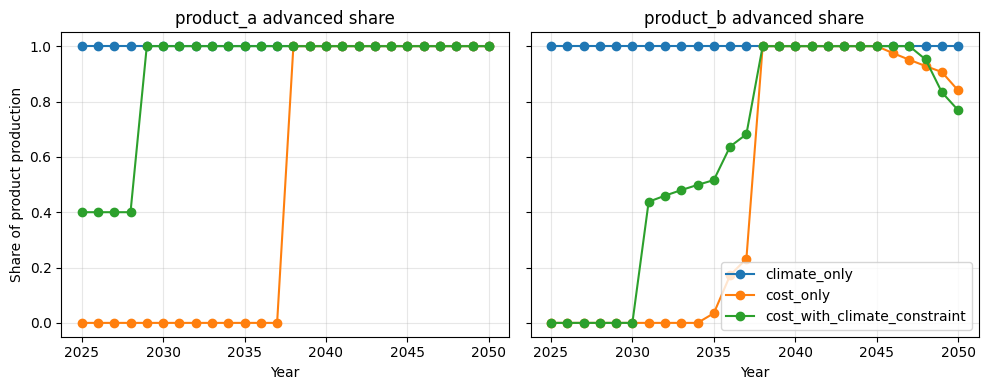

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, product in zip(axes, ["product_a", "product_b"]):
    for scenario, shares in advanced_share_tables.items():
        ax.plot(
            shares["year"],
            shares[f"{product}_advanced_share"],
            marker="o",
            label=scenario,
        )
    ax.set_title(f"{product} advanced share")
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Share of product production")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

### Cost by Year

In [57]:
def costs_by_year(model):
    return pd.DataFrame(
        [
            {
                "year": year,
                "discount_factor": pyo.value(model.discount_factor[year]),
                "installation_related_cost": pyo.value(model.cost_cap[year]),
                "operation_related_cost": pyo.value(model.cost_op[year]),
                "discounted_total": pyo.value(
                    model.discount_factor[year]
                    * (model.cost_cap[year] + model.cost_op[year])
                ),
            }
            for year in model.SYSTEM_TIME
        ]
    )


cost_by_year_tables = {
    "climate_only": costs_by_year(climate_model),
    "cost_only": costs_by_year(cost_model),
    "cost_with_climate_constraint": costs_by_year(constrained_model),
}

cost_by_year_tables["cost_only"].query(
    "installation_related_cost != 0 or operation_related_cost != 0"
).head(15)

,year,discount_factor,installation_related_cost,operation_related_cost,discounted_total
0,2025,1.000000,27.600000,124.800000,152.400000
1,2026,0.970874,3.652800,124.600320,124.517592
2,2027,0.942596,3.593600,124.337280,120.587124
3,2028,0.915142,3.534400,124.010880,116.721999
4,2029,0.888487,28.675200,123.621120,135.313308
5,2030,0.862609,3.416000,123.168000,109.192470
6,2031,0.837484,55.806800,122.651520,149.456033
7,2032,0.813092,3.297600,122.071680,101.936697
8,2033,0.789409,3.238400,121.428480,98.413186
9,2034,0.766417,3.179200,120.721920,94.959892


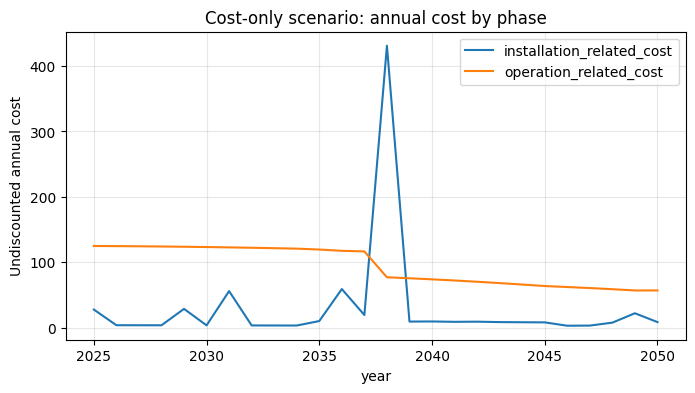

In [58]:
ax = cost_by_year_tables["cost_only"].plot(
    x="year",
    y=["installation_related_cost", "operation_related_cost"],
    figsize=(8, 4),
)
ax.set_ylabel("Undiscounted annual cost")
ax.set_title("Cost-only scenario: annual cost by phase")
ax.grid(True, alpha=0.3)
plt.show()

### Background Purchases and Costs

In [59]:
def background_purchases_by_year(model):
    rows = []
    for year in model.SYSTEM_TIME:
        for flow in model.INTERMEDIATE_FLOW:
            cap_purchase = pyo.value(model.background_purchase_cap[flow, year])
            op_purchase = pyo.value(model.background_purchase_op[flow, year])
            if abs(cap_purchase) > 1e-9:
                rows.append(
                    {
                        "phase": "installation_related",
                        "background_flow": flow,
                        "year": year,
                        "purchase_amount": cap_purchase,
                        "price": pyo.value(model.intermediate_costs_cap[flow, year]),
                        "cost": pyo.value(
                            model.intermediate_costs_cap[flow, year] * cap_purchase
                        ),
                    }
                )
            if abs(op_purchase) > 1e-9:
                rows.append(
                    {
                        "phase": "operation_related",
                        "background_flow": flow,
                        "year": year,
                        "purchase_amount": op_purchase,
                        "price": pyo.value(model.intermediate_costs_op[flow, year]),
                        "cost": pyo.value(
                            model.intermediate_costs_op[flow, year] * op_purchase
                        ),
                    }
                )
    return pd.DataFrame(rows)


background_purchase_costs = background_purchases_by_year(cost_model)
background_purchase_costs.head(15)

,phase,background_flow,year,purchase_amount,price,cost
0,installation_related,background_capex_1,2025,5.100,4.00,20.40000
1,installation_related,background_capex_2,2025,0.400,18.00,7.20000
2,operation_related,background_opex_3,2025,9.000,4.80,43.20000
3,operation_related,background_opex_1,2025,12.400,1.50,18.60000
4,operation_related,background_opex_2,2025,14.000,4.50,63.00000
5,installation_related,background_capex_1,2026,0.352,4.05,1.42560
6,installation_related,background_capex_2,2026,0.128,17.40,2.22720
7,operation_related,background_opex_3,2026,9.480,4.68,44.36640
8,operation_related,background_opex_1,2026,12.688,1.59,20.17392
9,operation_related,background_opex_2,2026,14.000,4.29,60.06000


### Capacity Balance for the Constrained Cost Scenario

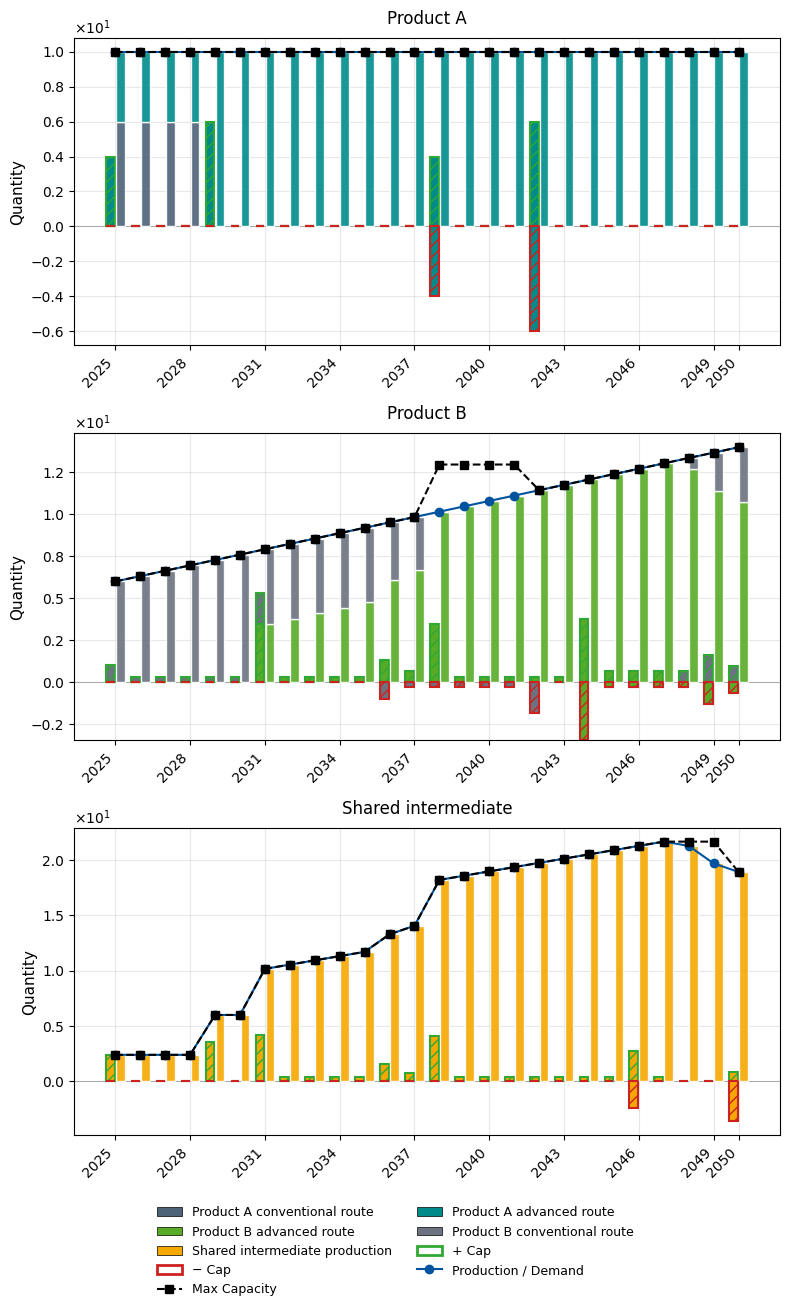

In [60]:
postprocessors["cost_with_climate_constraint"].plot_capacity_balance(detailed=True)

### Climate Impacts

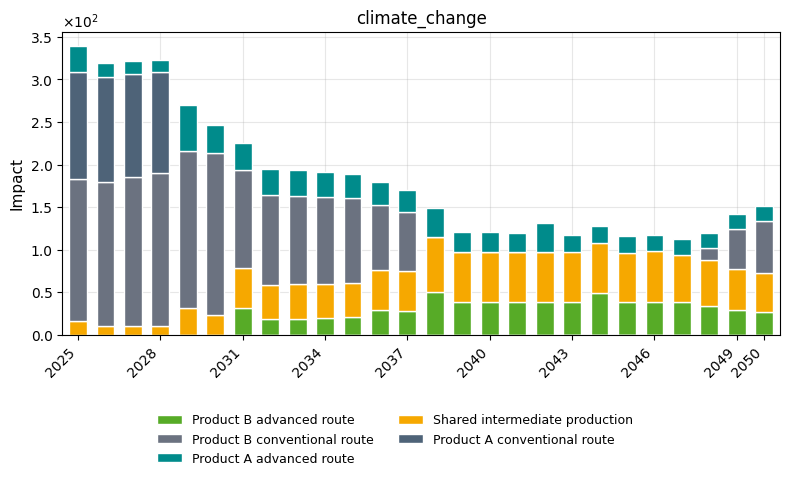

In [61]:
postprocessors["cost_with_climate_constraint"].plot_impacts()

## 6. Summary

This example demonstrates:

- the original climate-only `optimex` workflow,
- time-dependent market prices attached to first-level background inputs,
- installation-related and operation-related cost accounting based on `operation=True`,
- discounted economic cost minimization with `objective="cost"`,
- economic optimization under a cumulative climate budget,
- two final products and a shared intermediate as a small portfolio planning system.

The same cost objective can also be combined with deployment limits, operation limits, flow limits, or annual impact limits. This example uses only a cumulative climate budget to keep the trade-off easy to inspect.